# Waterfall Build-up — Incremental Component Analysis (3 × 3 Full Suite)

This notebook visualises the Pareto front progression as the algorithmic pipeline grows from a minimal baseline to the full proposed method, across **all 9 (dataset × hardware) combinations**.

| Stage | Label | Components |
|---|---|---|
| 1 | Random Search | Random sampling only |
| 2 | MOEA/D + GA | Decomposition + genetic operators |
| 3 | MOEA/D + GA + PSO | + Discrete PSO velocity update |
| 4 | Full Proposed | + Simulated Annealing local search |

**Budget:** 2 000 NFE per stage · **Seeds:** 30 seeds (0–29) per stage, all dataset × hardware combinations  
**Data source:** `results/waterfall/` (stages 1–3, produced by `scripts/run_waterfall.py`) + `results/cache/metrics/full_proposed/` (stage 4)  
**Structure:** 3 datasets (CIFAR-10 / CIFAR-100 / ImageNet-16) × 3 hardware (EdgeGPU / RPi-4 / Eyeriss)  
**Outputs:** 3×3 Pareto overlay grid · HV/IGD progression boxplots per combo · Metric summary table


In [6]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / 'src').exists() and (_parent / 'requirements.txt').exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError('Unable to locate the repository root for HW-NAS-Memetic.')
sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from src.analysis.data_loader import DATASETS, HARDWARE
from src.utils.pareto_math import to_display, normalise_to_bounds
from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd,
)
from src.utils.data_processing import load_archive as _load_json_archive

# ── Paths ─────────────────────────────────────────────────────────────────────
# Stage 1-3 results produced by scripts/run_waterfall.py (30 seeds each)
WATERFALL_BASE = PROJECT_ROOT / 'results' / 'waterfall'
FIGURES_DIR    = PROJECT_ROOT / 'results' / 'figures' / 'waterfall'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR          = PROJECT_ROOT / 'results' / 'cache'
CACHE_METRICS_ROOT = CACHE_DIR / 'metrics'
CACHE_PARETO_ROOT  = CACHE_DIR / 'pareto'
CACHE_METRICS_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_PARETO_ROOT.mkdir(parents=True, exist_ok=True)

SEEDS = list(range(30))

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size':  10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Stage catalogue ──────────────────────────────────────────────────────────
# (stem prefix, display label, colour)
STAGES = [
    ('stage1_random',       'Random Search',  '#7f7f7f'),
    ('stage2_moead_ga',     'MOEA/D + GA',    '#ff7f0e'),
    ('stage3_moead_ga_pso', 'MOEA/D+GA+PSO',  '#2ca02c'),
]
STAGE_IDS    = [stem for stem, _, _ in STAGES]
STAGE_LABELS = {stem: label for stem, label, _ in STAGES}
STAGE_COLORS = {stem: color for stem, _, color in STAGES}
STAGE_INDEX  = {stem: idx for idx, (stem, _, _) in enumerate(STAGES)}

FULL_CACHE_ID    = 'full_proposed'
FULL_CACHE_LABEL = 'Full Proposed'
FULL_CACHE_COLOR = '#1f77b4'
STAGE_INDEX[FULL_CACHE_ID] = len(STAGE_INDEX)
STAGE_PLOT_LABELS = [s[1] for s in STAGES] + [FULL_CACHE_LABEL]

# Set to True to ignore existing cache and recompute everything from scratch
FORCE_RECOMPUTE = False

REF = np.array([1.1, 1.1])

DS_LABEL = {
    'cifar10':        'CIFAR-10',
    'cifar100':       'CIFAR-100',
    'ImageNet16-120': 'ImageNet-16',
}
HW_LABEL = {
    'edgegpu_latency': 'EdgeGPU',
    'raspi4_latency':  'RPi-4',
    'eyeriss_latency': 'Eyeriss',
}


def _metrics_cache_path(stage_id):
    path = CACHE_METRICS_ROOT / stage_id / 'metrics.csv'
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def _pareto_cache_path(stage_id):
    path = CACHE_PARETO_ROOT / stage_id / 'pareto.csv'
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def _load_seed_archive(ds, hw, stage_stem, seed):
    return _load_json_archive(WATERFALL_BASE / ds / hw,
                              f'{stage_stem}_seed{seed}.json')


print('Setup complete.')
print(f'Datasets  : {DATASETS}')
print(f'Hardware  : {HARDWARE}')
print(f'Stages    : {[s[1] for s in STAGES]}')
print(f'Seeds     : {SEEDS[0]}..{SEEDS[-1]}  ({len(SEEDS)} total)')
print(f'Cache root: {CACHE_DIR}')
for stage_id in STAGE_IDS:
    p = _metrics_cache_path(stage_id)
    print(f'  {stage_id}: {p.relative_to(PROJECT_ROOT)}')
print(f'  {FULL_CACHE_ID}: {_metrics_cache_path(FULL_CACHE_ID).relative_to(PROJECT_ROOT)}')


PROJECT_ROOT = /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic
Setup complete.
Datasets  : ['cifar10', 'cifar100', 'ImageNet16-120']
Hardware  : ['edgegpu_latency', 'raspi4_latency', 'eyeriss_latency']
Stages    : ['Random Search', 'MOEA/D + GA', 'MOEA/D+GA+PSO']
Seeds     : 0..29  (30 total)
Cache root: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache
  stage1_random: results/cache/metrics/stage1_random/metrics.csv
  stage2_moead_ga: results/cache/metrics/stage2_moead_ga/metrics.csv
  stage3_moead_ga_pso: results/cache/metrics/stage3_moead_ga_pso/metrics.csv
  full_proposed: results/cache/metrics/full_proposed/metrics.csv


In [7]:
# ── Cell 2: Load / compute stage metrics (30 seeds) ──────────────────────────
# stage_data[ds][hw] = list of {label, color, acc, lat}  (aggregate Pareto)
stage_data     = {ds: {hw: [] for hw in HARDWARE} for ds in DATASETS}
metric_records = []

stage_paths  = {sid: _metrics_cache_path(sid) for sid in STAGE_IDS}
pareto_paths = {sid: _pareto_cache_path(sid)  for sid in STAGE_IDS}
full_metrics_path = _metrics_cache_path(FULL_CACHE_ID)
full_pareto_path  = _pareto_cache_path(FULL_CACHE_ID)
full_cache_available = full_metrics_path.exists() and full_pareto_path.exists()

_cached_metrics  = [sid for sid, p in stage_paths.items()  if p.exists()]
_cached_pareto   = [sid for sid, p in pareto_paths.items() if p.exists()]
_missing_metrics = [sid for sid in STAGE_IDS if sid not in _cached_metrics]
_missing_pareto  = [sid for sid in STAGE_IDS if sid not in _cached_pareto]

load_stage_cache = not FORCE_RECOMPUTE and not _missing_metrics and not _missing_pareto

if load_stage_cache:
    print('Loading waterfall stage data from per-stage cache:')
    for sid in STAGE_IDS:
        print(f'  {sid}: {stage_paths[sid]}')
    if full_cache_available:
        print(f'  full_proposed: {full_metrics_path}')

    metrics_df = pd.concat(
        [pd.read_csv(stage_paths[sid]) for sid in STAGE_IDS],
        ignore_index=True,
    )
    if full_cache_available:
        full_df = pd.read_csv(full_metrics_path)
        full_df['Stage']     = FULL_CACHE_LABEL
        full_df['stage_idx'] = STAGE_INDEX[FULL_CACHE_ID]
        full_df['stage_id']  = FULL_CACHE_ID
        metrics_df = pd.concat([metrics_df, full_df], ignore_index=True)

    for sid in STAGE_IDS:
        df = pd.read_csv(pareto_paths[sid])
        for (ds, hw), grp in df.groupby(['ds_key', 'hw_key']):
            if ds not in stage_data or hw not in stage_data[ds]:
                continue
            stage_data[ds][hw].append({
                'label': STAGE_LABELS[sid],
                'color': STAGE_COLORS[sid],
                'acc':   grp['acc'].values,
                'lat':   grp['lat'].values,
            })
    if full_cache_available:
        full_pareto = pd.read_csv(full_pareto_path)
        for (ds, hw), grp in full_pareto.groupby(['ds_key', 'hw_key']):
            if ds not in stage_data or hw not in stage_data[ds]:
                continue
            stage_data[ds][hw].append({
                'label': FULL_CACHE_LABEL,
                'color': FULL_CACHE_COLOR,
                'acc':   grp['acc'].values,
                'lat':   grp['lat'].values,
            })
    print(f'Loaded metrics for {len(metrics_df)} rows.')

else:
    # ── Compute metrics from 30-seed waterfall archives ───────────────────
    if FORCE_RECOMPUTE:
        print('FORCE_RECOMPUTE=True — rebuilding all stage caches.\n')
    elif _missing_metrics or _missing_pareto:
        print(f'Missing stage cache: metrics={_missing_metrics}, pareto={_missing_pareto}')
    if full_cache_available:
        print(f'Full stage cache available: {full_metrics_path}')
    print('Computing metrics from 30-seed waterfall archives ...\n')

    for ds in DATASETS:
        for hw in HARDWARE:
            all_fronts_pool = []
            seed_archives   = {sid: [] for sid in STAGE_IDS}

            for sid in STAGE_IDS:
                for seed in SEEDS:
                    try:
                        arch  = _load_seed_archive(ds, hw, sid, seed)
                        pts   = archive_to_points(arch)
                        front = get_pareto_front(pts)
                        seed_archives[sid].append((seed, front))
                        all_fronts_pool.append(front)
                    except FileNotFoundError:
                        pass

            if not all_fronts_pool:
                print(f'  [{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]  SKIP (no data)')
                continue

            proxy   = get_pareto_front(np.vstack(all_fronts_pool))
            pmin    = proxy.min(axis=0)
            prange  = np.where(proxy.max(axis=0) - pmin > 0,
                               proxy.max(axis=0) - pmin, 1.0)
            proxy_n = normalise_to_bounds(proxy, pmin, prange)

            print(f'  [{DS_LABEL[ds]:<12} x {HW_LABEL[hw]:<8}]')
            for sid, label, color in STAGES:
                stage_fronts = seed_archives[sid]
                if not stage_fronts:
                    print(f'    {STAGE_LABELS[sid]:<22}  MISSING')
                    for seed in SEEDS:
                        metric_records.append({
                            'Dataset':       DS_LABEL[ds],
                            'Hardware':      HW_LABEL[hw],
                            'ds_key':        ds,
                            'hw_key':        hw,
                            'Stage':         STAGE_LABELS[sid],
                            'stage_idx':     STAGE_INDEX[sid],
                            'stage_id':      sid,
                            'Seed':          seed,
                            'HV':            float('nan'),
                            'IGD':           float('nan'),
                            'Pareto Points': 0,
                        })
                    continue

                hvs, igds = [], []
                agg_front = None
                for seed, front in stage_fronts:
                    nf  = normalise_to_bounds(front, pmin, prange)
                    hv  = calc_hv(nf, ref_point=REF)
                    igd = calc_igd(nf, proxy_n)
                    hvs.append(hv)
                    igds.append(igd)
                    agg_front = front if agg_front is None else \
                                get_pareto_front(np.vstack([agg_front, front]))
                    metric_records.append({
                        'Dataset':       DS_LABEL[ds],
                        'Hardware':      HW_LABEL[hw],
                        'ds_key':        ds,
                        'hw_key':        hw,
                        'Stage':         STAGE_LABELS[sid],
                        'stage_idx':     STAGE_INDEX[sid],
                        'stage_id':      sid,
                        'Seed':          seed,
                        'HV':            hv,
                        'IGD':           igd,
                        'Pareto Points': len(front),
                    })

                print(f'    {STAGE_LABELS[sid]:<22}  '
                      f'HV={np.mean(hvs):.4f}+/-{np.std(hvs):.4f}  '
                      f'IGD={np.mean(igds):.4f}+/-{np.std(igds):.4f}  '
                      f'seeds={len(hvs)}')

                if agg_front is not None:
                    acc, lat = to_display(agg_front)
                    stage_data[ds][hw].append({
                        'label': STAGE_LABELS[sid],
                        'color': STAGE_COLORS[sid],
                        'acc':   acc,
                        'lat':   lat,
                    })

    metrics_df = pd.DataFrame(metric_records)

    # Attach Full Proposed from shared cache
    if full_cache_available:
        full_df = pd.read_csv(full_metrics_path)
        full_df['Stage']     = FULL_CACHE_LABEL
        full_df['stage_idx'] = STAGE_INDEX[FULL_CACHE_ID]
        full_df['stage_id']  = FULL_CACHE_ID
        metrics_df = pd.concat([metrics_df, full_df], ignore_index=True)
        full_pareto = pd.read_csv(full_pareto_path)
        for (ds, hw), grp in full_pareto.groupby(['ds_key', 'hw_key']):
            if ds not in stage_data or hw not in stage_data[ds]:
                continue
            stage_data[ds][hw].append({
                'label': FULL_CACHE_LABEL,
                'color': FULL_CACHE_COLOR,
                'acc':   grp['acc'].values,
                'lat':   grp['lat'].values,
            })
    else:
        print('Full Proposed cache not found -- stage 4 will be absent.')
        print(f'  Expected: {full_metrics_path}')

    # Save per-stage incremental caches
    for sid in STAGE_IDS:
        grp = metrics_df[metrics_df['stage_id'] == sid]
        if grp.empty:
            continue
        grp.to_csv(stage_paths[sid], index=False)
        print(f'Saved metrics cache: {stage_paths[sid].relative_to(PROJECT_ROOT)}')

    for sid in STAGE_IDS:
        pareto_records = []
        for ds in DATASETS:
            for hw in HARDWARE:
                entries = [e for e in stage_data[ds][hw]
                           if e['label'] == STAGE_LABELS[sid]]
                if not entries:
                    continue
                entry = entries[0]
                for a_val, l_val in zip(entry['acc'], entry['lat']):
                    pareto_records.append({
                        'ds_key':   ds,
                        'hw_key':   hw,
                        'stage_id': sid,
                        'acc':      a_val,
                        'lat':      l_val,
                    })
        if pareto_records:
            pd.DataFrame(pareto_records).to_csv(pareto_paths[sid], index=False)
            print(f'Saved pareto cache: {pareto_paths[sid].relative_to(PROJECT_ROOT)}')

print(f'Total metric rows: {len(metrics_df)}')
if 'Seed' in metrics_df.columns:
    n_seeds = metrics_df[metrics_df['stage_id'].isin(STAGE_IDS)]['Seed'].nunique()
    print(f'Unique seeds in incremental stages: {n_seeds}')


Missing stage cache: metrics=['stage1_random', 'stage2_moead_ga', 'stage3_moead_ga_pso'], pareto=['stage1_random', 'stage2_moead_ga', 'stage3_moead_ga_pso']
Full stage cache available: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/metrics/full_proposed/metrics.csv
Computing metrics from 30-seed waterfall archives ...

  [CIFAR-10     x EdgeGPU ]
    Random Search           HV=1.0462+/-0.0010  IGD=0.0117+/-0.0074  seeds=30
    MOEA/D + GA             HV=1.0485+/-0.0008  IGD=0.0074+/-0.0129  seeds=30
    MOEA/D+GA+PSO           HV=1.0476+/-0.0010  IGD=0.0094+/-0.0151  seeds=30
  [CIFAR-10     x RPi-4   ]
    Random Search           HV=1.1566+/-0.0006  IGD=0.0053+/-0.0016  seeds=30
    MOEA/D + GA             HV=1.1573+/-0.0008  IGD=0.0035+/-0.0014  seeds=30
    MOEA/D+GA+PSO           HV=1.1562+/-0.0011  IGD=0.0052+/-0.0020  seeds=30
  [CIFAR-10     x Eyeriss ]
    Random Search           HV=1.0102+/-0.0069  IGD=0.0515+/-0.0254  seeds=30
    MOEA/D + GA             HV=1

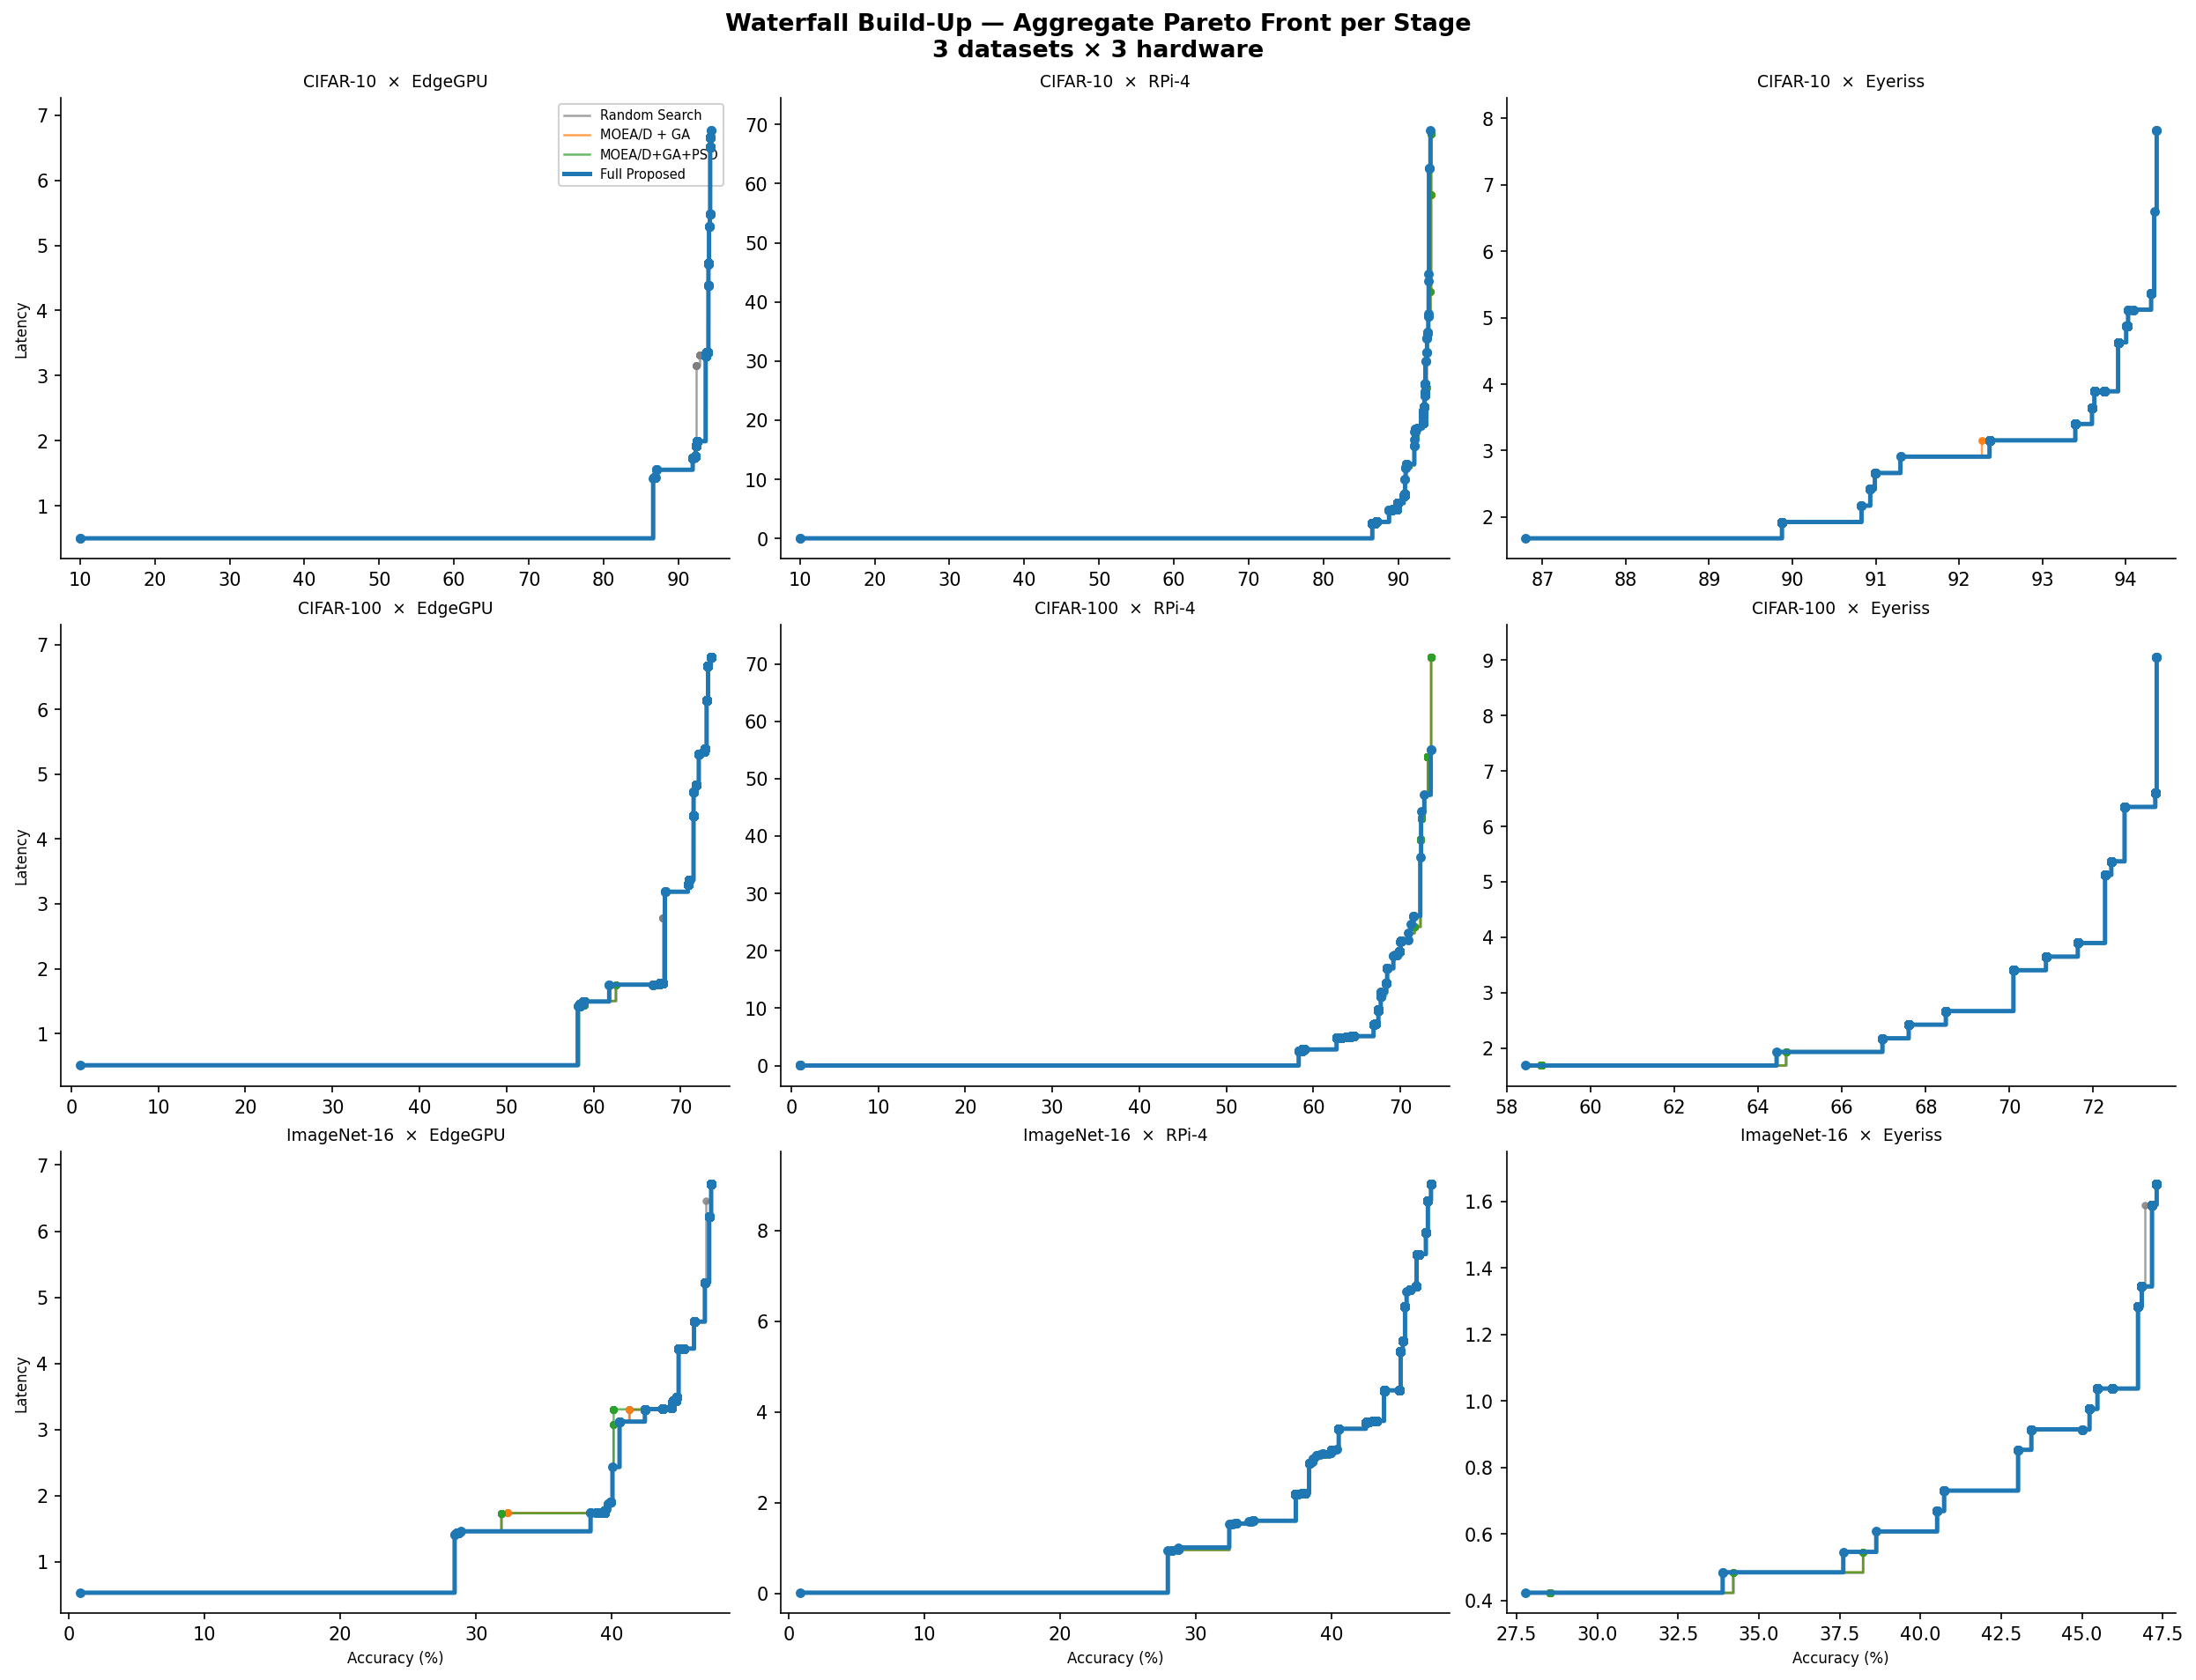

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_pareto.pdf


In [8]:
# ── Cell 3: 3×3 Pareto front overlay grid ────────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(DATASETS),
    ncols=len(HARDWARE),
    figsize=(5.5 * len(HARDWARE), 4.2 * len(DATASETS)),
    constrained_layout=True,
)
fig.suptitle(
    "Waterfall Build-Up — Aggregate Pareto Front per Stage\n"
    "3 datasets × 3 hardware",
    fontsize=13, fontweight="bold",
)

missing = []
for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax      = axes[r][c]
        entries = stage_data[ds][hw]

        if not entries:
            ax.text(0.5, 0.5, f"No data\n{DS_LABEL[ds]} / {HW_LABEL[hw]}",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="grey")
            ax.set_xticks([]); ax.set_yticks([])
            missing.append(f"{ds}/{hw}")
            continue

        all_acc = np.concatenate([e["acc"] for e in entries])
        all_lat = np.concatenate([e["lat"] for e in entries])
        xrng = max(all_acc.max() - all_acc.min(), 0.1)
        yrng = max(all_lat.max() - all_lat.min(), 1e-6)
        ax.set_xlim(all_acc.min() - xrng * 0.03, all_acc.max() + xrng * 0.03)
        ax.set_ylim(all_lat.min() - yrng * 0.05, all_lat.max() + yrng * 0.08)

        for entry in entries:
            is_full = entry["label"] == "Full Proposed"
            ax.step(entry["acc"], entry["lat"], where="post",
                    color=entry["color"],
                    linewidth=2.4 if is_full else 1.2,
                    alpha=1.0 if is_full else 0.72,
                    label=entry["label"],
                    zorder=10 if is_full else 4)
            ax.scatter(entry["acc"], entry["lat"],
                       s=18 if is_full else 10,
                       color=entry["color"],
                       alpha=1.0 if is_full else 0.72,
                       zorder=11 if is_full else 5)

        ax.set_title(f"{DS_LABEL[ds]}  ×  {HW_LABEL[hw]}", fontsize=9)
        if c == 0:
            ax.set_ylabel("Latency", fontsize=8)
        if r == len(DATASETS) - 1:
            ax.set_xlabel("Accuracy (%)", fontsize=8)
        if r == 0 and c == 0:
            ax.legend(fontsize=7, loc="upper right", ncol=1, framealpha=0.88)

grid_path = FIGURES_DIR / "waterfall_3x3_pareto.pdf"
plt.savefig(grid_path, bbox_inches="tight")
plt.show()
print(f"Saved → {grid_path}")
if missing:
    print(f"Missing combos: {', '.join(missing)}")


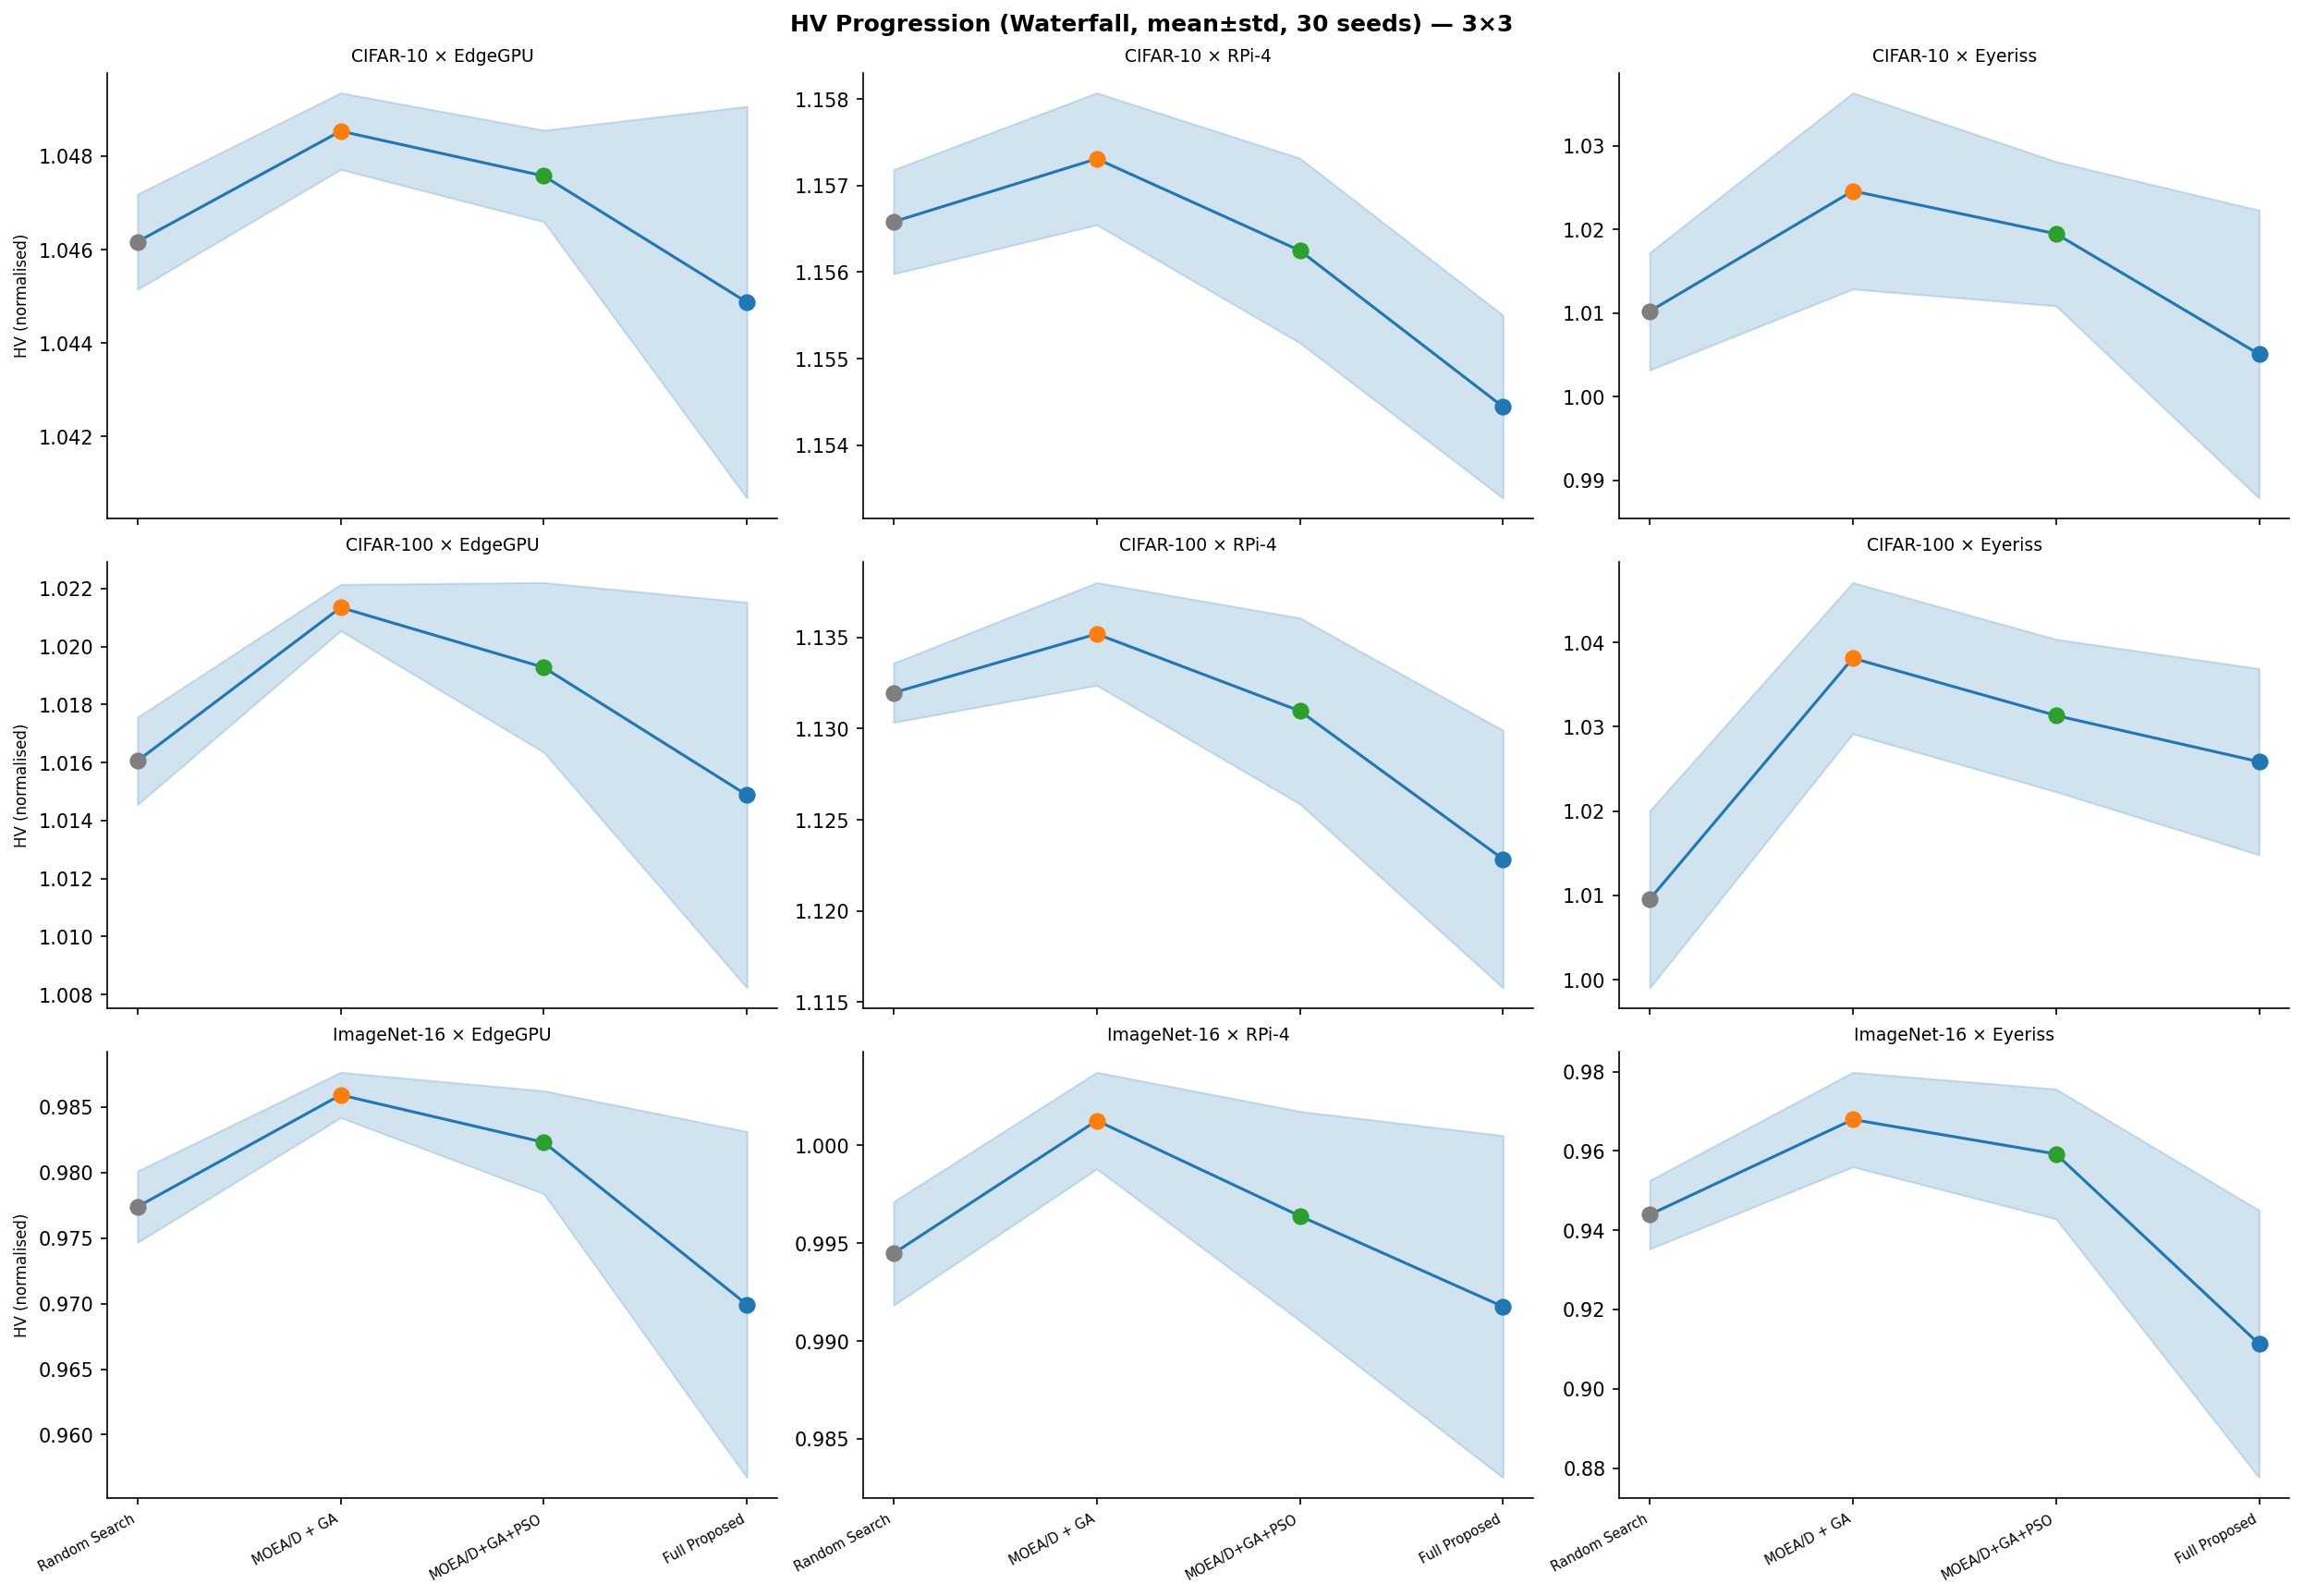

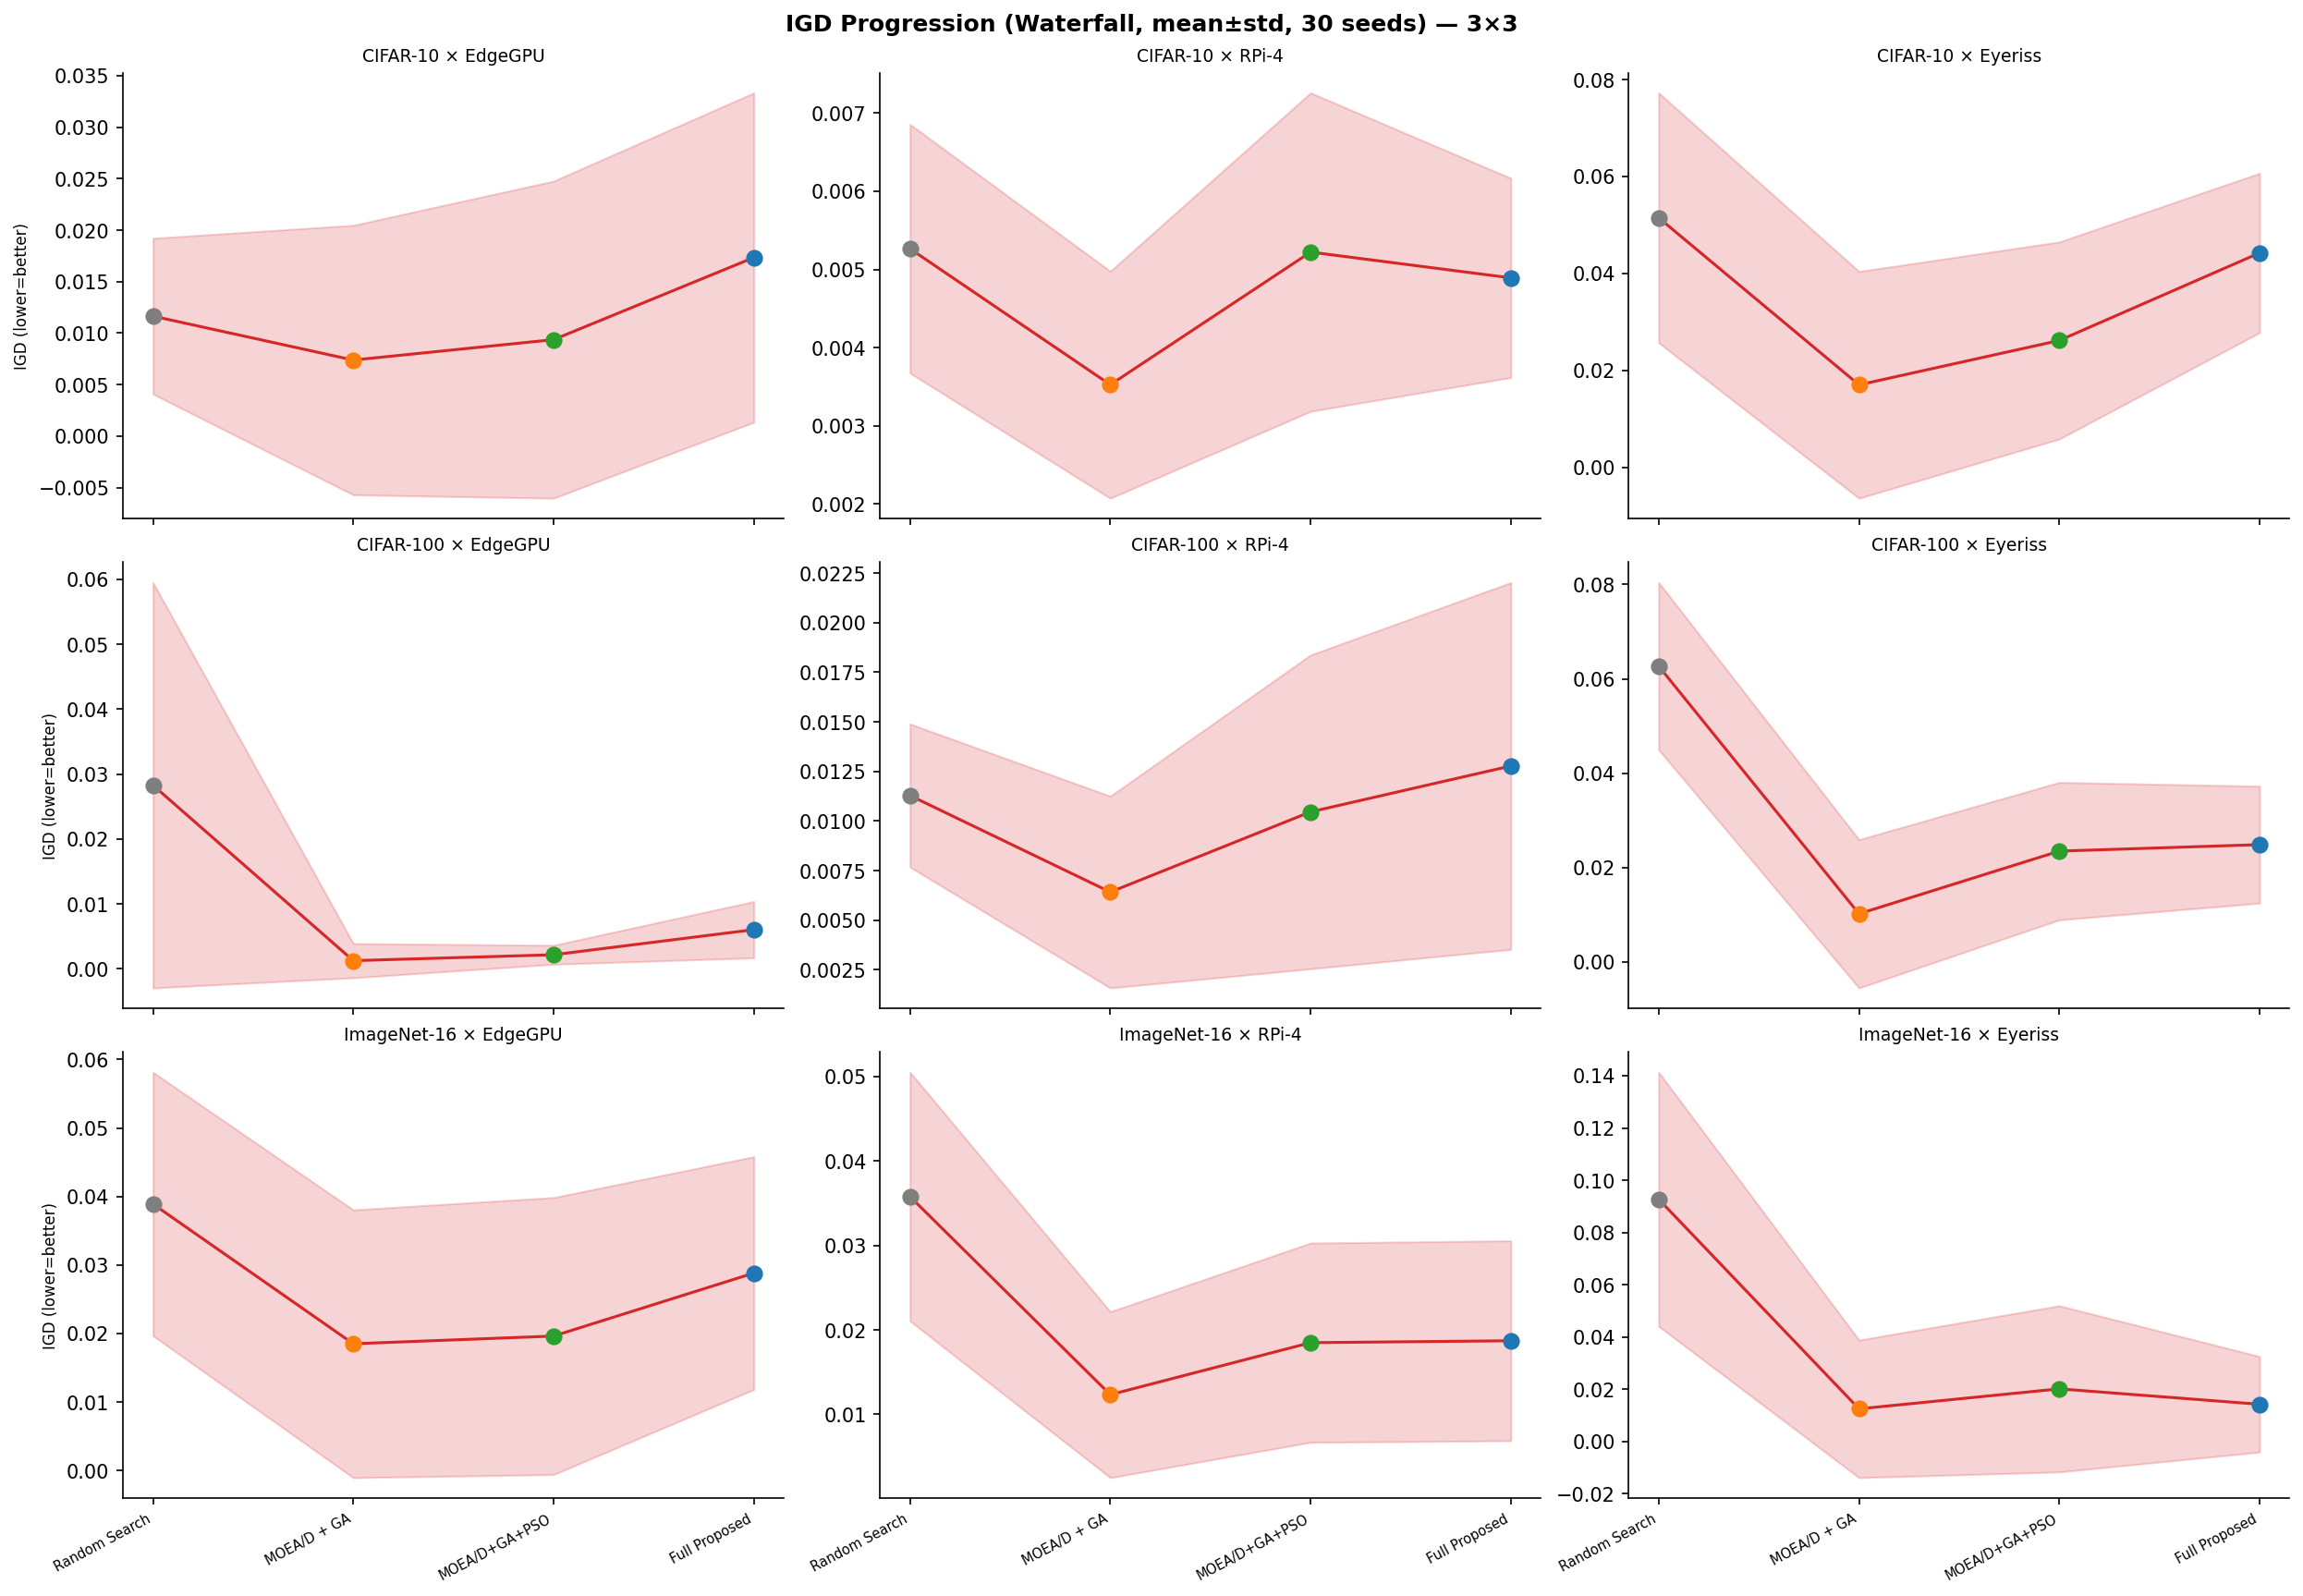

Saved -> /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_hv.pdf
Saved -> /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall/waterfall_3x3_igd.pdf


In [9]:
# ── Cell 4: 3×3 HV + IGD progression charts (mean ± std across 30 seeds) ────
all_stage_ids  = STAGE_IDS + [FULL_CACHE_ID]
all_stage_lbls = [STAGE_LABELS[s] for s in STAGE_IDS] + [FULL_CACHE_LABEL]
all_stage_clrs = [STAGE_COLORS[s] for s in STAGE_IDS] + [FULL_CACHE_COLOR]

fig_hv,  axes_hv  = plt.subplots(len(DATASETS), len(HARDWARE),
                                  figsize=(5.5 * len(HARDWARE), 3.8 * len(DATASETS)),
                                  constrained_layout=True, sharex=True)
fig_igd, axes_igd = plt.subplots(len(DATASETS), len(HARDWARE),
                                  figsize=(5.5 * len(HARDWARE), 3.8 * len(DATASETS)),
                                  constrained_layout=True, sharex=True)
fig_hv.suptitle("HV Progression (Waterfall, mean±std, 30 seeds) — 3×3",  fontsize=12, fontweight="bold")
fig_igd.suptitle("IGD Progression (Waterfall, mean±std, 30 seeds) — 3×3", fontsize=12, fontweight="bold")

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax_hv  = axes_hv[r][c]
        ax_igd = axes_igd[r][c]
        subset = metrics_df[
            (metrics_df['ds_key'] == ds) & (metrics_df['hw_key'] == hw)
        ]

        if subset.empty or subset['HV'].isna().all():
            for ax in (ax_hv, ax_igd):
                ax.text(0.5, 0.5, "No data", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, color='grey')
                ax.set_xticks([]); ax.set_yticks([])
            continue

        stats = (
            subset.groupby('stage_idx')[['HV', 'IGD']]
            .agg(['mean', 'std'])
            .reset_index()
        )
        stats.columns = ['stage_idx', 'HV_mean', 'HV_std', 'IGD_mean', 'IGD_std']
        stats = stats.sort_values('stage_idx')
        xs       = stats['stage_idx'].values
        hv_mean  = stats['HV_mean'].values
        hv_std   = stats['HV_std'].fillna(0).values
        igd_mean = stats['IGD_mean'].values
        igd_std  = stats['IGD_std'].fillna(0).values
        colors   = [all_stage_clrs[i] for i in xs]

        # HV panel
        ax_hv.plot(xs, hv_mean, '-', color='#1f77b4', linewidth=1.5)
        ax_hv.fill_between(xs, hv_mean - hv_std, hv_mean + hv_std,
                           color='#1f77b4', alpha=0.20)
        for xi, hvi, ci in zip(xs, hv_mean, colors):
            ax_hv.scatter(xi, hvi, color=ci, s=60, zorder=5)
        ax_hv.set_xticks(xs)
        ax_hv.set_xticklabels([all_stage_lbls[i] for i in xs],
                              rotation=28, ha='right', fontsize=7)
        ax_hv.set_title(f'{DS_LABEL[ds]} × {HW_LABEL[hw]}', fontsize=9)
        if c == 0: ax_hv.set_ylabel('HV (normalised)', fontsize=8)

        # IGD panel
        ax_igd.plot(xs, igd_mean, '-', color='#d62728', linewidth=1.5)
        ax_igd.fill_between(xs, igd_mean - igd_std, igd_mean + igd_std,
                            color='#d62728', alpha=0.20)
        for xi, igdi, ci in zip(xs, igd_mean, colors):
            ax_igd.scatter(xi, igdi, color=ci, s=60, zorder=5)
        ax_igd.set_xticks(xs)
        ax_igd.set_xticklabels([all_stage_lbls[i] for i in xs],
                               rotation=28, ha='right', fontsize=7)
        ax_igd.set_title(f'{DS_LABEL[ds]} × {HW_LABEL[hw]}', fontsize=9)
        if c == 0: ax_igd.set_ylabel('IGD (lower=better)', fontsize=8)

fig_hv.savefig(FIGURES_DIR / 'waterfall_3x3_hv.pdf',  bbox_inches='tight')
fig_igd.savefig(FIGURES_DIR / 'waterfall_3x3_igd.pdf', bbox_inches='tight')
plt.show()
print(f'Saved -> {FIGURES_DIR}/waterfall_3x3_hv.pdf')
print(f'Saved -> {FIGURES_DIR}/waterfall_3x3_igd.pdf')


In [10]:
# ── Cell 5: Summary table — ΔHV and ΔIGD from each stage to Full ─────────────
if not metrics_df.empty:
    if FULL_CACHE_ID not in metrics_df["stage_id"].unique():
        print("⚠ Full Proposed metrics are not available in the current dataset. Ensure results/cache/metrics/full_proposed/metrics.csv exists.")
    else:
        full_df = metrics_df[metrics_df["stage_id"] == FULL_CACHE_ID].copy()
        full_mean = (
            full_df.groupby(["Dataset", "Hardware"])[["HV", "IGD"]]
            .mean()
            .reset_index()
            .rename(columns={"HV": "HV_full", "IGD": "IGD_full"})
        )

        stage_summary = (
            metrics_df[metrics_df["stage_id"] != FULL_CACHE_ID]
            .groupby(["Dataset", "Hardware", "Stage", "stage_idx"], as_index=False)[["HV", "IGD"]]
            .mean()
        )

        merged = stage_summary.merge(full_mean, on=["Dataset", "Hardware"], how="left")
        merged["ΔHV"]  = merged["HV_full"] - merged["HV"]
        merged["ΔIGD"] = merged["IGD_full"] - merged["IGD"]
        merged = merged.sort_values(["Dataset", "Hardware", "stage_idx"])

        display_cols = [
            "Stage", "Dataset", "Hardware",
            "HV", "HV_full", "ΔHV",
            "IGD", "IGD_full", "ΔIGD",
        ]
        print(f"Stage comparison vs Full Proposed (all incremental stages):\n")
        print(merged[display_cols].to_string(index=False))

        merged.to_csv(FIGURES_DIR / "waterfall_stage_vs_full_summary.csv", index=False)
        print(f"\nSaved → {FIGURES_DIR}/waterfall_stage_vs_full_summary.csv")

Stage comparison vs Full Proposed (all incremental stages):

        Stage     Dataset Hardware       HV  HV_full       ΔHV      IGD  IGD_full      ΔIGD
Random Search    CIFAR-10  EdgeGPU 1.046168 1.044872 -0.001296 0.011651  0.017343  0.005692
  MOEA/D + GA    CIFAR-10  EdgeGPU 1.048535 1.044872 -0.003663 0.007387  0.017343  0.009955
MOEA/D+GA+PSO    CIFAR-10  EdgeGPU 1.047575 1.044872 -0.002703 0.009368  0.017343  0.007975
Random Search    CIFAR-10  Eyeriss 1.010214 1.005088 -0.005126 0.051458  0.044210 -0.007248
  MOEA/D + GA    CIFAR-10  Eyeriss 1.024618 1.005088 -0.019531 0.016993  0.044210  0.027216
MOEA/D+GA+PSO    CIFAR-10  Eyeriss 1.019498 1.005088 -0.014410 0.026147  0.044210  0.018062
Random Search    CIFAR-10    RPi-4 1.156582 1.154443 -0.002139 0.005265  0.004892 -0.000373
  MOEA/D + GA    CIFAR-10    RPi-4 1.157310 1.154443 -0.002868 0.003524  0.004892  0.001368
MOEA/D+GA+PSO    CIFAR-10    RPi-4 1.156249 1.154443 -0.001806 0.005222  0.004892 -0.000330
Random Search   CIF